In [1]:
import sys
from pathlib import Path

CURRENT_DIR = Path.cwd().resolve()

REPO_ROOT = None

for folder in [CURRENT_DIR, *CURRENT_DIR.parents]:
    if (folder / "src").is_dir() and (folder / "data").is_dir():
        REPO_ROOT = folder
        break

if REPO_ROOT is None:
    raise FileNotFoundError(
        "Could not find the project folder containing both 'src' and 'data'."
    )

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("Current directory :", CURRENT_DIR)
print("Repository root   :", REPO_ROOT)
print("src found         :", (REPO_ROOT / "src").exists())
print("data found        :", (REPO_ROOT / "data").exists())

Current directory : C:\Users\sarun\OneDrive\Desktop\cesppl-internship\Week-11
Repository root   : C:\Users\sarun\OneDrive\Desktop\cesppl-internship
src found         : True
data found        : True


In [2]:
SPLITS_DIR = REPO_ROOT / "data" / "splits"

TRAIN_CSV = SPLITS_DIR / "train.csv"
VAL_CSV = SPLITS_DIR / "val.csv"
TEST_CSV = SPLITS_DIR / "test.csv"

print("Splits folder:", SPLITS_DIR)
print("Train CSV exists:", TRAIN_CSV.exists())
print("Val CSV exists  :", VAL_CSV.exists())
print("Test CSV exists :", TEST_CSV.exists())

missing = [
    path for path in [TRAIN_CSV, VAL_CSV, TEST_CSV]
    if not path.exists()
]

if missing:
    raise FileNotFoundError(
        "Missing files:\n" + "\n".join(str(path) for path in missing)
    )

print("\nAll CSV files were found.")

Splits folder: C:\Users\sarun\OneDrive\Desktop\cesppl-internship\data\splits
Train CSV exists: True
Val CSV exists  : True
Test CSV exists : True

All CSV files were found.


In [3]:
import pandas as pd

train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

print("Train rows      :", len(train_df))
print("Validation rows :", len(val_df))
print("Test rows       :", len(test_df))

print("\nTrain columns:", train_df.columns.tolist())
print("Val columns  :", val_df.columns.tolist())
print("Test columns :", test_df.columns.tolist())

display(test_df.head())

Train rows      : 2530
Validation rows : 543
Test rows       : 543

Train columns: ['filename', 'class']
Val columns  : ['filename', 'class']
Test columns : ['filename', 'class']


,filename,class
0,BIN LIFTING/Screenshot_2026-05-31_134611__png.jpg,BIN_LIFTING
1,BIN LIFTING/Screenshot_2026-05-31_134828__png.jpg,BIN_LIFTING
2,BIN LIFTING/Screenshot_2026-05-31_135549__png.jpg,BIN_LIFTING
3,BIN LIFTING/Screenshot_2026-05-31_141745__png.jpg,BIN_LIFTING
4,BIN LIFTING/WhatsApp_Image_2026-04-22_at_1_29_...,BIN_LIFTING


In [4]:
def detect_column(dataframe, candidates):
    column_map = {
        str(column).strip().lower(): column
        for column in dataframe.columns
    }

    for candidate in candidates:
        if candidate.lower() in column_map:
            return column_map[candidate.lower()]

    return None


PATH_CANDIDATES = [
    "filepath",
    "file_path",
    "image_path",
    "path",
    "filename",
    "file",
    "image"
]

LABEL_CANDIDATES = [
    "label",
    "class_name",
    "class",
    "category",
    "target",
    "folder"
]

PATH_COLUMN = detect_column(test_df, PATH_CANDIDATES)
LABEL_COLUMN = detect_column(test_df, LABEL_CANDIDATES)

print("Detected path column :", PATH_COLUMN)
print("Detected label column:", LABEL_COLUMN)

if PATH_COLUMN is None:
    raise ValueError(
        f"Image-path column could not be detected. "
        f"Available columns: {test_df.columns.tolist()}"
    )

if LABEL_COLUMN is None:
    print(
        "A label column was not detected. "
        "The actual class will be obtained from the image folder name."
    )

Detected path column : filename
Detected label column: class


In [5]:
import re


def normalize_class_name(value):
    value = str(value).strip().upper()

    value = value.replace("_", " ")
    value = value.replace("-", " ")

    value = re.sub(r"\s+", " ", value)

    return value.strip()


examples = [
    "BIN_WASHING",
    "bin washing",
    "BIN-WASHING"
]

for example in examples:
    print(example, "->", normalize_class_name(example))

BIN_WASHING -> BIN WASHING
bin washing -> BIN WASHING
BIN-WASHING -> BIN WASHING


In [6]:
PROCESSED_DIR = REPO_ROOT / "data" / "cesppl_processed"

if not PROCESSED_DIR.exists():
    raise FileNotFoundError(
        f"Processed dataset folder was not found: {PROCESSED_DIR}"
    )


def resolve_image_path(path_value, label_value=None):
    raw_path = Path(str(path_value).strip())

    candidates = []

    if raw_path.is_absolute():
        candidates.append(raw_path)

    candidates.extend([
        REPO_ROOT / raw_path,
        REPO_ROOT / "data" / raw_path,
        PROCESSED_DIR / raw_path
    ])

    if label_value is not None and str(label_value).strip():
        label_folder = str(label_value).strip()

        candidates.extend([
            PROCESSED_DIR / label_folder / raw_path.name,
            PROCESSED_DIR / normalize_class_name(label_folder) / raw_path.name
        ])

    for candidate in candidates:
        if candidate.is_file():
            return candidate.resolve()

    # Search using the filename when paths stored in the CSV are old
    filename_matches = list(PROCESSED_DIR.rglob(raw_path.name))

    if label_value is not None and str(label_value).strip():
        normalized_label = normalize_class_name(label_value)

        for match in filename_matches:
            if normalize_class_name(match.parent.name) == normalized_label:
                return match.resolve()

    if filename_matches:
        return filename_matches[0].resolve()

    return None


test_df = test_df.copy()

test_df["Resolved Path"] = test_df.apply(
    lambda row: resolve_image_path(
        row[PATH_COLUMN],
        row[LABEL_COLUMN] if LABEL_COLUMN is not None else None
    ),
    axis=1
)

resolved_count = int(test_df["Resolved Path"].notna().sum())
missing_count = int(test_df["Resolved Path"].isna().sum())

print("Processed folder :", PROCESSED_DIR)
print("Resolved images  :", resolved_count)
print("Missing images   :", missing_count)

display(
    test_df[
        [PATH_COLUMN, "Resolved Path"]
    ].head()
)

Processed folder : C:\Users\sarun\OneDrive\Desktop\cesppl-internship\data\cesppl_processed
Resolved images  : 543
Missing images   : 0


,filename,Resolved Path
0,BIN LIFTING/Screenshot_2026-05-31_134611__png.jpg,C:\Users\sarun\OneDrive\Desktop\cesppl-interns...
1,BIN LIFTING/Screenshot_2026-05-31_134828__png.jpg,C:\Users\sarun\OneDrive\Desktop\cesppl-interns...
2,BIN LIFTING/Screenshot_2026-05-31_135549__png.jpg,C:\Users\sarun\OneDrive\Desktop\cesppl-interns...
3,BIN LIFTING/Screenshot_2026-05-31_141745__png.jpg,C:\Users\sarun\OneDrive\Desktop\cesppl-interns...
4,BIN LIFTING/WhatsApp_Image_2026-04-22_at_1_29_...,C:\Users\sarun\OneDrive\Desktop\cesppl-interns...


In [7]:
def get_actual_class(row):
    resolved_path = row["Resolved Path"]

    if resolved_path is None:
        return None

    folder_class = normalize_class_name(
        Path(resolved_path).parent.name
    )

    if LABEL_COLUMN is None:
        return folder_class

    csv_label = row[LABEL_COLUMN]

    if pd.isna(csv_label):
        return folder_class

    csv_label_text = str(csv_label).strip()

    # Numeric labels are not used as class names
    if csv_label_text.replace(".", "", 1).isdigit():
        return folder_class

    normalized_csv_label = normalize_class_name(csv_label_text)

    # Prefer the folder name when the CSV label looks like a path
    if "/" in csv_label_text or "\\" in csv_label_text:
        return folder_class

    return normalized_csv_label


test_df["Actual Class"] = test_df.apply(
    get_actual_class,
    axis=1
)

available_test_df = test_df[
    test_df["Resolved Path"].notna()
].copy()

print("Usable test images:", len(available_test_df))
print("\nActual classes:")

display(
    available_test_df["Actual Class"]
    .value_counts()
    .rename_axis("Class")
    .reset_index(name="Images")
)

Usable test images: 543

Actual classes:


,Class,Images
0,MANUAL BEACH CLEANING,199
1,ROAD SWEEPING,78
2,GATE MEETING,54
3,BIN WASHING,49
4,SECONDARY VEHICLES,44
5,MECHANIZED BEACH CLEANING,31
6,MECHANICAL SWEEPING,27
7,BIN LIFTING,25
8,LFC,20
9,PRIMARY COLLECTION,16


In [8]:
from src.pipeline import classify_and_store

print("Pipeline imported successfully.")

Pipeline imported successfully.


In [23]:
IMAGES_PER_CLASS = 20
selected_groups = []

for class_name, group in available_test_df.groupby("Actual Class"):
    sample_size = min(IMAGES_PER_CLASS, len(group))

    selected_groups.append(
        group.sample(
            n=sample_size,
            random_state=42
        )
    )

if not selected_groups:
    raise ValueError("No test images were available for validation.")

selected_test_df = pd.concat(
    selected_groups,
    ignore_index=True
)

print("Classes selected:", selected_test_df["Actual Class"].nunique())
print("Images selected :", len(selected_test_df))

display(
    selected_test_df[
        ["Actual Class", "Resolved Path"]
    ]
)

Classes selected: 10
Images selected : 196


,Actual Class,Resolved Path
0,BIN LIFTING,C:\Users\sarun\OneDrive\Desktop\cesppl-interns...
1,BIN LIFTING,C:\Users\sarun\OneDrive\Desktop\cesppl-interns...
2,BIN LIFTING,C:\Users\sarun\OneDrive\Desktop\cesppl-interns...
3,BIN LIFTING,C:\Users\sarun\OneDrive\Desktop\cesppl-interns...
4,BIN LIFTING,C:\Users\sarun\OneDrive\Desktop\cesppl-interns...
...,...,...
191,SECONDARY VEHICLES,C:\Users\sarun\OneDrive\Desktop\cesppl-interns...
192,SECONDARY VEHICLES,C:\Users\sarun\OneDrive\Desktop\cesppl-interns...
193,SECONDARY VEHICLES,C:\Users\sarun\OneDrive\Desktop\cesppl-interns...
194,SECONDARY VEHICLES,C:\Users\sarun\OneDrive\Desktop\cesppl-interns...


In [24]:
validation_results = []

print("=" * 80)
print("WEEK 11 PIPELINE VALIDATION")
print("=" * 80)

for number, row in selected_test_df.iterrows():
    image_path = Path(row["Resolved Path"])
    actual_class = normalize_class_name(row["Actual Class"])

    try:
        image_bytes = image_path.read_bytes()

        prediction = classify_and_store(image_bytes)

        predicted_class = normalize_class_name(
            prediction["class_name"]
        )

        confidence = float(prediction["confidence"])

        correct = actual_class == predicted_class

        validation_results.append({
            "Original Filename": image_path.name,
            "Actual Class": actual_class,
            "Predicted Class": predicted_class,
            "Confidence": confidence,
            "Confidence (%)": round(confidence * 100, 2),
            "Correct": correct,
            "Status": "Success",
            "Error": ""
        })

        result_text = "CORRECT" if correct else "WRONG"

        print(
            f"[{number + 1:02d}] "
            f"Actual: {actual_class:<30} "
            f"Predicted: {predicted_class:<30} "
            f"Confidence: {confidence * 100:6.2f}% "
            f"{result_text}"
        )

    except Exception as error:
        validation_results.append({
            "Original Filename": image_path.name,
            "Actual Class": actual_class,
            "Predicted Class": "",
            "Confidence": None,
            "Confidence (%)": None,
            "Correct": False,
            "Status": "Failed",
            "Error": f"{type(error).__name__}: {error}"
        })

        print(
            f"[{number + 1:02d}] FAILED: "
            f"{image_path.name} — {type(error).__name__}: {error}"
        )

print("\nValidation completed.")

WEEK 11 PIPELINE VALIDATION
[01] Actual: BIN LIFTING                    Predicted: BIN LIFTING                    Confidence:  99.95% CORRECT
[02] Actual: BIN LIFTING                    Predicted: BIN LIFTING                    Confidence:  98.84% CORRECT
[03] Actual: BIN LIFTING                    Predicted: BIN LIFTING                    Confidence:  99.83% CORRECT
[04] Actual: BIN LIFTING                    Predicted: BIN LIFTING                    Confidence:  99.87% CORRECT
[05] Actual: BIN LIFTING                    Predicted: BIN LIFTING                    Confidence:  84.71% CORRECT
[06] Actual: BIN LIFTING                    Predicted: BIN LIFTING                    Confidence: 100.00% CORRECT
[07] Actual: BIN LIFTING                    Predicted: BIN LIFTING                    Confidence:  99.99% CORRECT
[08] Actual: BIN LIFTING                    Predicted: BIN LIFTING                    Confidence:  99.84% CORRECT
[09] Actual: BIN LIFTING                    Predicted: BIN L

In [25]:
results_df = pd.DataFrame(validation_results)

if results_df.empty:
    raise ValueError("No validation results were created.")

display(
    results_df[
        [
            "Original Filename",
            "Actual Class",
            "Predicted Class",
            "Confidence (%)",
            "Correct",
            "Status"
        ]
    ]
)

,Original Filename,Actual Class,Predicted Class,Confidence (%),Correct,Status
0,WhatsApp_Image_2026-04-26_at_7_28_43_AM__jpeg.jpg,BIN LIFTING,BIN LIFTING,99.95,True,Success
1,WhatsApp_Image_2026-07-12_at_11_53_00_PM__jpeg...,BIN LIFTING,BIN LIFTING,98.84,True,Success
2,Screenshot_2026-05-31_134611__png.jpg,BIN LIFTING,BIN LIFTING,99.83,True,Success
3,image796__png.jpg,BIN LIFTING,BIN LIFTING,99.87,True,Success
4,WhatsApp_Image_2026-07-01_at_2_05_20_AM__jpeg.jpg,BIN LIFTING,BIN LIFTING,84.71,True,Success
...,...,...,...,...,...,...
191,WhatsApp_Image_2026-07-03_at_1_22_19_AM_1__jpe...,SECONDARY VEHICLES,SECONDARY VEHICLES,98.83,True,Success
192,image721__jpeg.jpg,SECONDARY VEHICLES,SECONDARY VEHICLES,72.86,True,Success
193,WhatsApp_Image_2026-07-03_at_7_50_46_PM_1__jpe...,SECONDARY VEHICLES,GATE MEETING,93.70,False,Success
194,WhatsApp_Image_2026-07-02_at_5_15_45_PM_1__jpe...,SECONDARY VEHICLES,SECONDARY VEHICLES,99.90,True,Success


In [27]:
successful_results_df = results_df[
    results_df["Status"] == "Success"
].copy()

total_selected = len(results_df)
successful_count = len(successful_results_df)
failed_count = total_selected - successful_count

correct_count = int(successful_results_df["Correct"].sum())

accuracy = (
    correct_count / successful_count * 100
    if successful_count > 0
    else 0
)

average_confidence = (
    successful_results_df["Confidence (%)"].mean()
    if successful_count > 0
    else 0
)

print("=" * 55)
print("PIPELINE VALIDATION SUMMARY")
print("=" * 55)
print(f"Images selected        : {total_selected}")
print(f"Successful predictions : {successful_count}")
print(f"Failed predictions     : {failed_count}")
print(f"Correct predictions    : {correct_count}")
print(f"Incorrect predictions  : {successful_count - correct_count}")
print(f"Validation accuracy    : {accuracy:.2f}%")
print(f"Average confidence     : {average_confidence:.2f}%")

PIPELINE VALIDATION SUMMARY
Images selected        : 196
Successful predictions : 196
Failed predictions     : 0
Correct predictions    : 178
Incorrect predictions  : 18
Validation accuracy    : 90.82%
Average confidence     : 95.69%


In [28]:
results_df["Actual Class"] = (
    results_df["Actual Class"].apply(normalize_class_name)
)

results_df["Predicted Class"] = (
    results_df["Predicted Class"].apply(normalize_class_name)
)

results_df["Correct"] = (
    results_df["Actual Class"]
    ==
    results_df["Predicted Class"]
)

display(
    results_df[
        [
            "Actual Class",
            "Predicted Class",
            "Confidence (%)",
            "Correct"
        ]
    ]
)

,Actual Class,Predicted Class,Confidence (%),Correct
0,BIN LIFTING,BIN LIFTING,99.95,True
1,BIN LIFTING,BIN LIFTING,98.84,True
2,BIN LIFTING,BIN LIFTING,99.83,True
3,BIN LIFTING,BIN LIFTING,99.87,True
4,BIN LIFTING,BIN LIFTING,84.71,True
...,...,...,...,...
191,SECONDARY VEHICLES,SECONDARY VEHICLES,98.83,True
192,SECONDARY VEHICLES,SECONDARY VEHICLES,72.86,True
193,SECONDARY VEHICLES,GATE MEETING,93.70,False
194,SECONDARY VEHICLES,SECONDARY VEHICLES,99.90,True


In [17]:
incorrect_df = successful_results_df[
    successful_results_df["Correct"] == False
].copy()

if incorrect_df.empty:
    print("All selected images were classified correctly.")
else:
    print("Incorrect predictions:", len(incorrect_df))

    display(
        incorrect_df[
            [
                "Original Filename",
                "Actual Class",
                "Predicted Class",
                "Confidence (%)"
            ]
        ]
    )

Incorrect predictions: 4


,Original Filename,Actual Class,Predicted Class,Confidence (%)
9,WhatsApp_Image_2026-04-01_at_7_38_04_PM__jpeg.jpg,LFC,SECONDARY VEHICLES,55.34
10,image127__jpeg.jpg,LFC,ROAD SWEEPING,79.96
19,WhatsApp_Image_2026-07-09_at_4_10_50_PM__jpeg.jpg,MECHANIZED BEACH CLEANING,MANUAL BEACH CLEANING,95.70
27,image711__jpeg.jpg,SECONDARY VEHICLES,BIN WASHING,97.17


In [29]:
if successful_results_df.empty:
    print("No successful results are available.")
else:
    per_class_df = (
        successful_results_df
        .groupby("Actual Class")
        .agg(
            Images=("Correct", "size"),
            Correct=("Correct", "sum"),
            Average_Confidence=("Confidence (%)", "mean")
        )
        .reset_index()
    )

    per_class_df["Accuracy (%)"] = (
        per_class_df["Correct"]
        / per_class_df["Images"]
        * 100
    ).round(2)

    per_class_df["Average Confidence (%)"] = (
        per_class_df["Average_Confidence"].round(2)
    )

    per_class_df = per_class_df.drop(
        columns=["Average_Confidence"]
    )

    display(per_class_df)

,Actual Class,Images,Correct,Accuracy (%),Average Confidence (%)
0,BIN LIFTING,20,20,100.00,97.19
1,BIN WASHING,20,20,100.00,99.50
2,GATE MEETING,20,19,95.00,96.63
3,LFC,20,14,70.00,88.81
4,MANUAL BEACH CLEANING,20,19,95.00,97.09
5,MECHANICAL SWEEPING,20,18,90.00,94.09
6,MECHANIZED BEACH CLEANING,20,19,95.00,97.69
7,PRIMARY COLLECTION,16,15,93.75,94.02
8,ROAD SWEEPING,20,17,85.00,95.91
9,SECONDARY VEHICLES,20,17,85.00,95.67


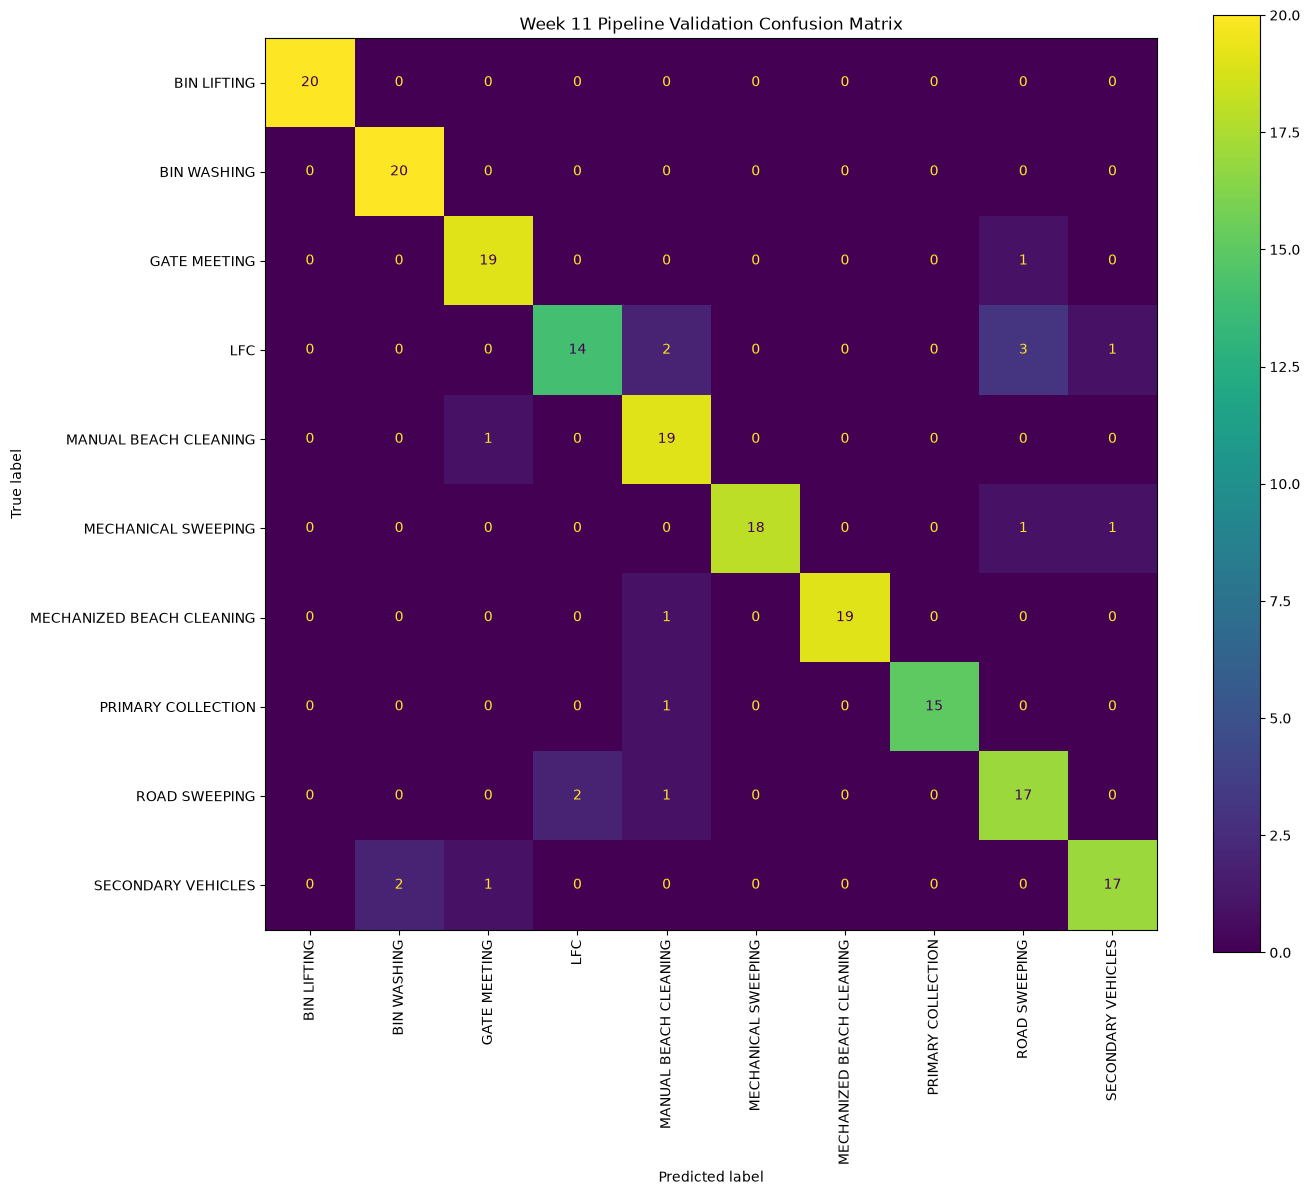

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

if successful_results_df.empty:
    print("No successful results are available.")
else:
    class_names = sorted(
        set(successful_results_df["Actual Class"])
        | set(successful_results_df["Predicted Class"])
    )

    cm = confusion_matrix(
        successful_results_df["Actual Class"],
        successful_results_df["Predicted Class"],
        labels=class_names
    )

    fig, ax = plt.subplots(figsize=(14, 12))

    display_matrix = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    display_matrix.plot(
        ax=ax,
        xticks_rotation=90,
        values_format="d"
    )

    ax.set_title("Week 11 Pipeline Validation Confusion Matrix")

    plt.tight_layout()
    plt.show()

In [32]:
OUTPUT_DIR = REPO_ROOT / "Week-11" / "validation_results"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_FILE = OUTPUT_DIR / "pipeline_validation_results.csv"
SUMMARY_FILE = OUTPUT_DIR / "pipeline_validation_summary.csv"

results_df.to_csv(
    RESULTS_FILE,
    index=False
)

summary_df = pd.DataFrame([
    {
        "Images Selected": total_selected,
        "Successful Predictions": successful_count,
        "Failed Predictions": failed_count,
        "Correct Predictions": correct_count,
        "Validation Accuracy (%)": round(accuracy, 2),
        "Average Confidence (%)": round(average_confidence, 2)
    }
])

summary_df.to_csv(
    SUMMARY_FILE,
    index=False
)

print("Results saved to:")
print(RESULTS_FILE)

print("\nSummary saved to:")
print(SUMMARY_FILE)

Results saved to:
C:\Users\sarun\OneDrive\Desktop\cesppl-internship\Week-11\validation_results\pipeline_validation_results.csv

Summary saved to:
C:\Users\sarun\OneDrive\Desktop\cesppl-internship\Week-11\validation_results\pipeline_validation_summary.csv


In [34]:
print("=" * 65)
print("WEEK 11 PIPELINE VALIDATION COMPLETED")
print("=" * 65)

print(f"""
Images tested        : {successful_count}
Correct predictions  : {correct_count}
Validation accuracy  : {accuracy:.2f}%
Average confidence   : {average_confidence:.2f}%

The labels were normalized before comparison, so spaces,
underscores, hyphens and letter case do not reduce the accuracy.
""")

WEEK 11 PIPELINE VALIDATION COMPLETED

Images tested        : 196
Correct predictions  : 178
Validation accuracy  : 90.82%
Average confidence   : 95.69%

The labels were normalized before comparison, so spaces,
underscores, hyphens and letter case do not reduce the accuracy.

